In [1]:
import pandas as pd

In [13]:
import seaborn as sns
import numpy as np

In [3]:
data=pd.read_csv('Marksheet.csv')

In [4]:
df=pd.DataFrame(data)

In [27]:
df.head(2)

,sr no,Branch,Enrolment No,Name,Roll No,Div,Mentor Name,TEST-1 MARKS,TEST-2 MARKS,TEST-3 MARKS,TEST-4 MARKS,Total Marks,Grade
0,1,CE,2.200220e+13,KATHIRIYA VRAJKUMAR ASHVINBHAI,110,A4,UMM,14.5,18.0,22.5,14.5,69.5,C
1,2,CE,2.300220e+13,AGRAVAT SAHIL RAJARAMBHAI,101,A3,SAS,14.0,20.0,19.0,14.0,67.0,C


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sr no         302 non-null    int64  
 1   Branch        302 non-null    object 
 2   Enrolment No  302 non-null    float64
 3   Name          302 non-null    object 
 4   Roll No       302 non-null    int64  
 5   Div           302 non-null    object 
 6   Mentor Name   301 non-null    object 
 7   TEST-1 MARKS  302 non-null    float64
 8   TEST-2 MARKS  302 non-null    float64
 9   TEST-3 MARKS  302 non-null    float64
 10  TEST-4 MARKS  302 non-null    float64
 11  Total Marks   302 non-null    float64
 12  Grade         302 non-null    object 
dtypes: float64(6), int64(2), object(5)
memory usage: 30.8+ KB


In [29]:
df['TEST-1 MARKS']=df['TEST-1 MARKS'].replace('AB',0)
df['TEST-2 MARKS']=df['TEST-2 MARKS'].replace('AB',0)
df['TEST-3 MARKS']=df['TEST-3 MARKS'].replace('AB',0)
df['TEST-4 MARKS']=df['TEST-4 MARKS'].replace('AB',0)

In [30]:
df['TEST-1 MARKS']=df['TEST-1 MARKS'].astype(float)
df['TEST-2 MARKS']=df['TEST-2 MARKS'].astype(float)
df['TEST-3 MARKS']=df['TEST-3 MARKS'].astype(float)
df['TEST-4 MARKS']=df['TEST-4 MARKS'].astype(float)

In [31]:
df['Total Marks']=df['TEST-1 MARKS']  + df['TEST-2 MARKS'] + df['TEST-3 MARKS']+df['TEST-4 MARKS']

In [32]:
df.head(3)

,sr no,Branch,Enrolment No,Name,Roll No,Div,Mentor Name,TEST-1 MARKS,TEST-2 MARKS,TEST-3 MARKS,TEST-4 MARKS,Total Marks,Grade
0,1,CE,2.200220e+13,KATHIRIYA VRAJKUMAR ASHVINBHAI,110,A4,UMM,14.5,18.0,22.5,14.5,69.5,C
1,2,CE,2.300220e+13,AGRAVAT SAHIL RAJARAMBHAI,101,A3,SAS,14.0,20.0,19.0,14.0,67.0,C
2,3,CE,2.300220e+13,BALAR RAGHUBHAI SURESHBHAI,162,A5,KMS,19.0,20.5,19.0,19.0,77.5,B


In [33]:
df['Grade']=np.where(df['Total Marks']>85,'A',np.where(df['Total Marks']>75,'B',np.where(df['Total Marks']>65,'C',np.where(df['Total Marks']>50,'D',np.where(df['Total Marks']>35,'E','F')))))

In [34]:
df.head()

,sr no,Branch,Enrolment No,Name,Roll No,Div,Mentor Name,TEST-1 MARKS,TEST-2 MARKS,TEST-3 MARKS,TEST-4 MARKS,Total Marks,Grade
0,1,CE,2.200220e+13,KATHIRIYA VRAJKUMAR ASHVINBHAI,110,A4,UMM,14.5,18.0,22.5,14.5,69.5,C
1,2,CE,2.300220e+13,AGRAVAT SAHIL RAJARAMBHAI,101,A3,SAS,14.0,20.0,19.0,14.0,67.0,C
2,3,CE,2.300220e+13,BALAR RAGHUBHAI SURESHBHAI,162,A5,KMS,19.0,20.5,19.0,19.0,77.5,B
3,4,CE,2.300220e+13,BALESANA HASSANBHAI YUNUSBHAI,122,A4,UMM,22.0,17.5,9.0,22.0,70.5,C
4,5,CE,2.300220e+13,BAMBHROLIYA HIT NARESHBHAI,87,A3,UMS,24.0,22.0,21.5,24.0,91.5,A


In [35]:
df.groupby('Div')['Total Marks'].mean()

Div
A1    92.229730
A2    82.337838
A3    77.785714
A4    72.600000
A5    69.400000
A6    54.291667
A7    43.348485
A8    72.946429
A9    49.923077
Name: Total Marks, dtype: float64

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x=df[['TEST-1 MARKS']]
y=df['Total Marks']


In [37]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(x_train,y_train)
print(lr.coef_)
print(lr.intercept_)
y_pred=lr.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
# model=LinearRegression()


[3.05504506]
15.813787110275165
4.562882441915474
31.095179823163477
0.9294439835710049


0.9370739328687248
46


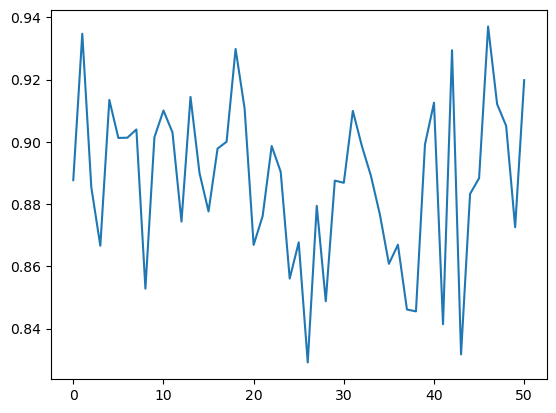

In [40]:
import matplotlib.pyplot as plt
r2=[]
for i in range(0,51):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=i)
    lr=LinearRegression()
    lr.fit(x_train,y_train)
    y_pred=lr.predict(x_test)
    r2.append(r2_score(y_test,y_pred))
plt.plot(r2)
print(max(r2))
print(r2.index(max(r2)))